# Coleta de Dados e Pandas

In [1]:
# Apenas para MacOS, para resolver o problema de certificado SSL
import os
os.environ['SSL_CERT_FILE'] = '/etc/ssl/cert.pem'
os.environ['REQUESTS_CA_BUNDLE'] = '/etc/ssl/cert.pem'

In [2]:
# biblioteca para requisição
# !pip install --upgrade pip
# !pip install requests
# !pip install matplotlib
# !pip install openpyxl
# !pip install --upgrade certifi
# !pip install missingno
# !pip install scikit-learn

## Importações de Bibliotecas

In [3]:
import requests
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

import missingno as msno
from scipy import stats
from sklearn.impute import KNNImputer

## Módulo 02

### Tipos de Instância | Series

In [4]:
data = pd.Series([0.24, 0.5, 0.75, 1])
data

0    0.24
1    0.50
2    0.75
3    1.00
dtype: float64

In [5]:
data.values

array([0.24, 0.5 , 0.75, 1.  ])

In [6]:
data[1]

np.float64(0.5)

In [7]:
data[1:3]

1    0.50
2    0.75
dtype: float64

In [8]:
populacao_ne = {
    'Fortaleza': 2428678,
    'Salvador' : 2418005,
    'Recife' : 1488920,
    'São Luís' : 1037775,
    'Maceió' : 957916,
    'Teresina' : 866300,
    'João Pessoa' : 833932
}
populacao = pd.Series(populacao_ne)

In [9]:
populacao

Fortaleza      2428678
Salvador       2418005
Recife         1488920
São Luís       1037775
Maceió          957916
Teresina        866300
João Pessoa     833932
dtype: int64

### Tipos de Instâncias | Dataframe

In [10]:
pop_ne = [2418005, 1488920, 833932]
area = [692.818, 218.843, 211.745]

In [11]:
estados = pd.DataFrame(
    {'populacao': pop_ne,
    'area':area})

In [12]:
estados

,populacao,area
0,2418005,692.818
1,1488920,218.843
2,833932,211.745


In [13]:
estados.columns

Index(['populacao', 'area'], dtype='str')

In [14]:
estados['area']

0    692.818
1    218.843
2    211.745
Name: area, dtype: float64

### Tipos de Instância | Series

In [15]:
ind = pd.Index([2, 3, 5, 7, 11])

In [16]:
ind

Index([2, 3, 5, 7, 11], dtype='int64')

In [17]:
ind[1]

np.int64(3)

In [18]:
ind[::2]

Index([2, 5, 11], dtype='int64')

In [19]:
ind[::3]

Index([2, 7], dtype='int64')

### 1. API pública do IBGE — estados do Brasil

In [20]:
URL_IBGE = "https://servicodados.ibge.gov.br/api/v1/localidades/estados"

In [21]:
response = requests.get(URL_IBGE)

In [22]:
print(response.status_code)  # 200 = OK

200


In [23]:
print(response.json())

[{'id': 11, 'sigla': 'RO', 'nome': 'Rondônia', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 12, 'sigla': 'AC', 'nome': 'Acre', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 13, 'sigla': 'AM', 'nome': 'Amazonas', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 14, 'sigla': 'RR', 'nome': 'Roraima', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 15, 'sigla': 'PA', 'nome': 'Pará', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 16, 'sigla': 'AP', 'nome': 'Amapá', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 17, 'sigla': 'TO', 'nome': 'Tocantins', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 21, 'sigla': 'MA', 'nome': 'Maranhão', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 22, 'sigla': 'PI', 'nome': 'Piauí', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 23, 'sigla': 'CE', 'nome': 'Ceará', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 24, 'si

In [24]:
estados = response.json()

In [25]:
# pd.DataFrame(estados) converte a lista de dicionários retornada pela API em um DataFrame.
# [["id","sigla","nome"]] seleciona apenas as colunas desejadas,
# descartando outras como "regiao" que também vêm na resposta da API.
df_estados = pd.DataFrame(estados)[["id","sigla","nome"]]

In [26]:
print(df_estados.head())

   id sigla      nome
0  11    RO  Rondônia
1  12    AC      Acre
2  13    AM  Amazonas
3  14    RR   Roraima
4  15    PA      Pará


### 2. Carregar CSV / XLSX via URL

In [27]:
url_xlsx = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

In [28]:
df_xlsx = pd.read_excel(url_xlsx)  # pode funcionar

In [29]:
df_xlsx.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### Alternativa em CSV

In [30]:
url_csv = "https://raw.githubusercontent.com/prof-mrafaelbatista/261_UNIESP_MBA-DADOS_data_mining_inferencia_estatistica/refs/heads/main/datasets/OnlineRetail.csv"

In [31]:
df = pd.read_csv(url_csv, encoding='latin1')

In [32]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Inspeção Básica

In [33]:
print(df.shape) # (linhas, colunas)

(541909, 8)


In [34]:
print(df.dtypes) # tipos de cada coluna

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [35]:
print(df.head(6)) # mostra as 6 primeiras linhas do DataFrame

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5    536365     22752         SET 7 BABUSHKA NESTING BOXES         2   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
5  12/1/2010 8:26       7.65     17850.0  United Kingdom  


In [36]:
print(df.info()) # informações gerais sobre o DataFrame, incluindo contagem de valores não nulos e tipos de dados   

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


In [37]:
print(df.describe()) # estatísticas descritivas para colunas numéricas, como média, desvio padrão, mínimo, máximo e quartis 

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


#### Gráficos

<Axes: title={'center': 'Quantidade por Preço Unitário'}, xlabel='UnitPrice'>

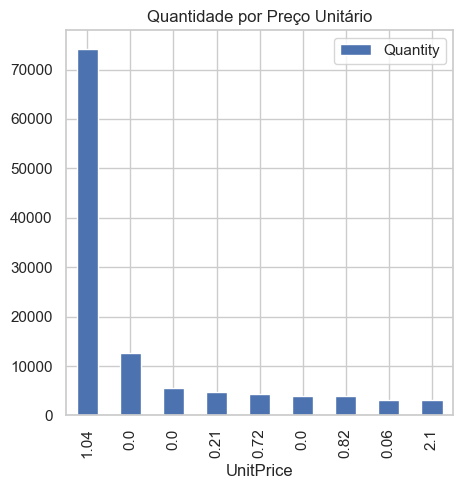

In [38]:
df.sort_values(by='Quantity', ascending=False).iloc[1:10, :].plot.bar(
    x='UnitPrice',
    y='Quantity',
    title='Quantidade por Preço Unitário',
    figsize=(5, 5),
    rot=90)

In [39]:
df['QuantityMaior'] = np.where(
    (df.Quantity>10),
    'Sim',
    'Não')

## Módulo 03

### Impacto de Outlier

In [40]:
# Exemplo de impacto de outlier na média
salarios = [1200, 1400, 1500, 1600, 1800, 2000, 2200, 2500, 50000]  # CEO incluído
s = pd.Series(salarios)

In [41]:
print(f"Média: R$ {s.mean():,.0f}")
print(f"Mediana: R$ {s.median():,.0f}")
print(f"Moda: R$ {s.mode()[0]:,.0f}")

Média: R$ 7,133
Mediana: R$ 1,800
Moda: R$ 1,200


### Carregamento do Dataset - OnlineRetail

In [42]:
url_csv = "https://raw.githubusercontent.com/prof-mrafaelbatista/261_UNIESP_MBA-DADOS_data_mining_inferencia_estatistica/refs/heads/main/datasets/OnlineRetail.csv"

In [43]:
df = pd.read_csv(url_csv, encoding='latin1')

In [44]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Inspeção Básica

In [45]:
print(df['Quantity'].mean())

9.55224954743324


In [46]:
print(df['Quantity'].median())

3.0


In [47]:
# print(df['UnitPrice'].mean())
print(f"{df['UnitPrice'].mean():.2f}")


4.61


In [48]:
print(df['UnitPrice'].median())

2.08


In [49]:
# Classificação de variáveis
print(df.dtypes)  # object = categórico, int64/float64 = numérico

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [50]:
print(df['Country'].nunique(), "países distintos")  # variável nominal

38 países distintos


## Módulo 04

In [51]:
# Exemplo: mesma média, dispersão diferente
time_a = pd.Series([4, 4, 4, 4, 4])
time_b = pd.Series([1, 3, 4, 5, 7])
print(f"Time A: média={time_a.mean()}, DP={time_a.std():.2f}")
print(f"Time B: média={time_b.mean()}, DP={time_b.std():.2f}")

Time A: média=4.0, DP=0.00
Time B: média=4.0, DP=2.24


In [52]:
# Variância e DP do UnitPrice
print(f"Variância UnitPrice: {df['UnitPrice'].var():.2f}")
print(f"Desvio Padrão UnitPrice: {df['UnitPrice'].std():.2f}")

Variância UnitPrice: 9362.47
Desvio Padrão UnitPrice: 96.76


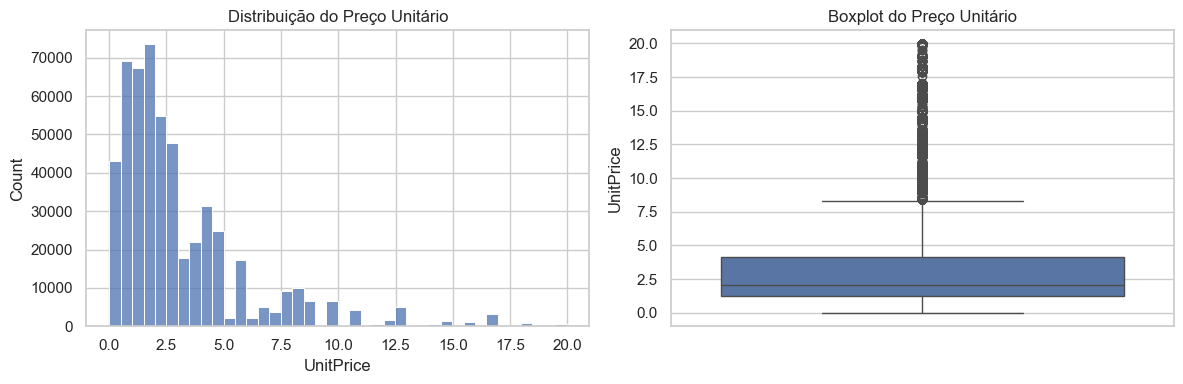

In [53]:
# Histograma
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_filtered = df[(df['UnitPrice'] < 20) & (df['UnitPrice'] > 0)]  # remover outliers extremos para visualização
sns.histplot(df_filtered['UnitPrice'], bins=40, ax=axes[0])
axes[0].set_title('Distribuição do Preço Unitário')

# Boxplot
sns.boxplot(y=df_filtered['UnitPrice'], ax=axes[1])
axes[1].set_title('Boxplot do Preço Unitário')
plt.tight_layout()
plt.show()

/var/folders/7q/z180l3ln4ts4149fxshv0zh00000gn/T/ipykernel_15896/3214029740.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.values, y=top_paises.index, palette='Blues_d')


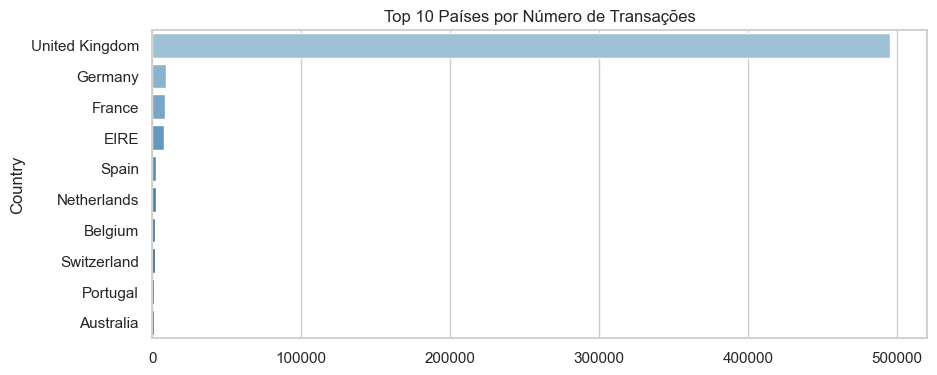

In [54]:
# Gráfico de barras — top 10 países
top_paises = df['Country'].value_counts().head(10)
plt.figure(figsize=(10,4))
sns.barplot(x=top_paises.values, y=top_paises.index, palette='Blues_d')
plt.title('Top 10 Países por Número de Transações')
plt.show()

### Outros exemplos

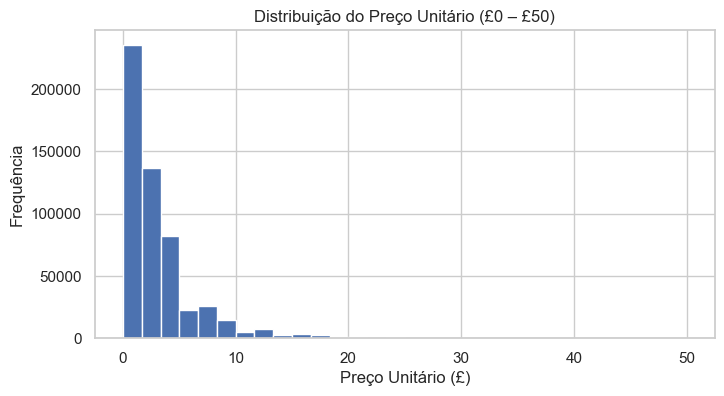

In [55]:
preco_filtrado = df[df['UnitPrice'].between(0, 50)]['UnitPrice']
preco_filtrado.plot(kind='hist', bins=30, edgecolor='white', figsize=(8,4))
plt.title('Distribuição do Preço Unitário (£0 – £50)')
plt.xlabel('Preço Unitário (£)')
plt.ylabel('Frequência')
plt.show()

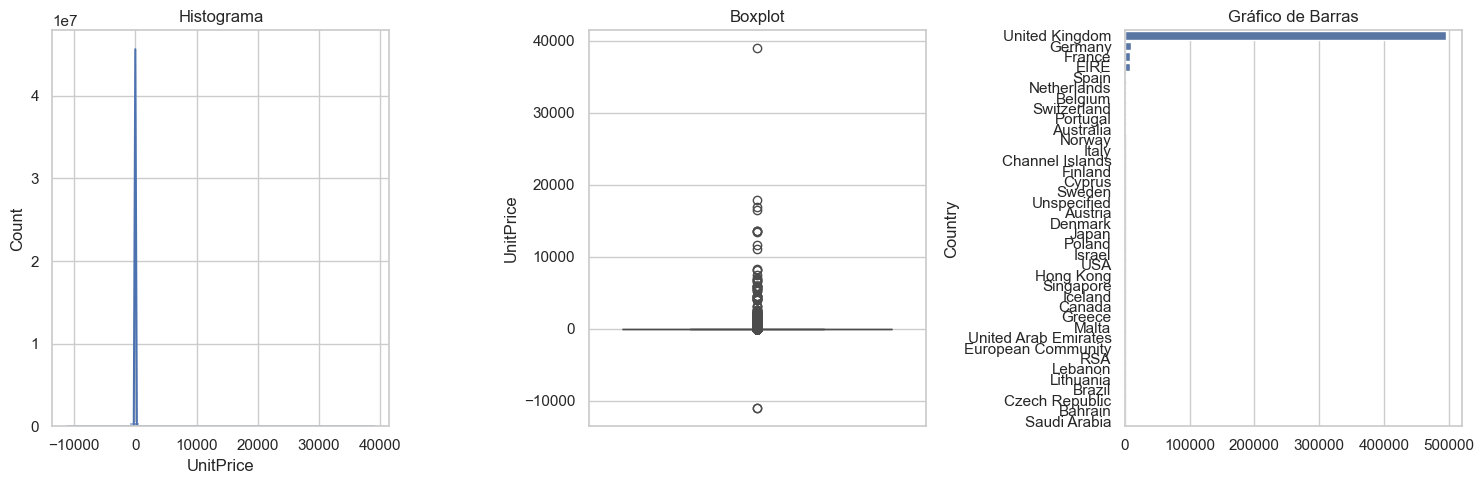

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['UnitPrice'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Histograma')

sns.boxplot(y=df['UnitPrice'], ax=axes[1])
axes[1].set_title('Boxplot')

freq = df['Country'].value_counts()
sns.barplot(x=freq.values, y=freq.index, ax=axes[2])
axes[2].set_title('Gráfico de Barras')

plt.tight_layout()
plt.show()

## Laboratório 01

### Calcule média, mediana e desvio padrão das colunas 'Quantity' e 'UnitPrice'. Compare média e mediana — o que você conclui sobre a distribuição?

In [57]:
df[['Quantity','UnitPrice']].agg(['mean','median','std']).round(2)

,Quantity,UnitPrice
mean,9.55,4.61
median,3.00,2.08
std,218.08,96.76


### Gere um histograma de 'UnitPrice' filtrando apenas valores entre 0 e 20. Descreva o formato da distribuição.


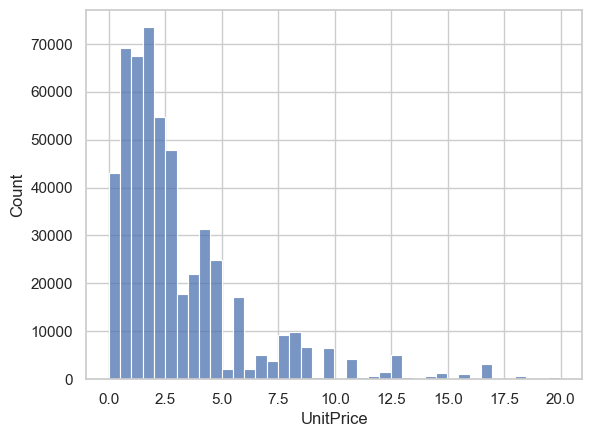

In [58]:
df_f = df[(df['UnitPrice']>0)&(df['UnitPrice']<20)]
sns.histplot(df_f['UnitPrice'], bins=40)
plt.show()

### Gere um boxplot de 'Quantity' filtrando valores entre 0 e 100. Identifique visualmente o Q1, mediana e Q3

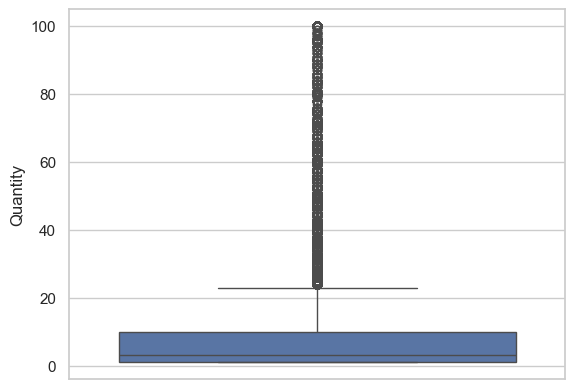

In [59]:
df_q = df[(df['Quantity']>0)&(df['Quantity']<=100)]
sns.boxplot(y=df_q['Quantity'])
plt.show()

### Qual o top 5 de países com mais transações? Gere um gráfico de barras horizontais

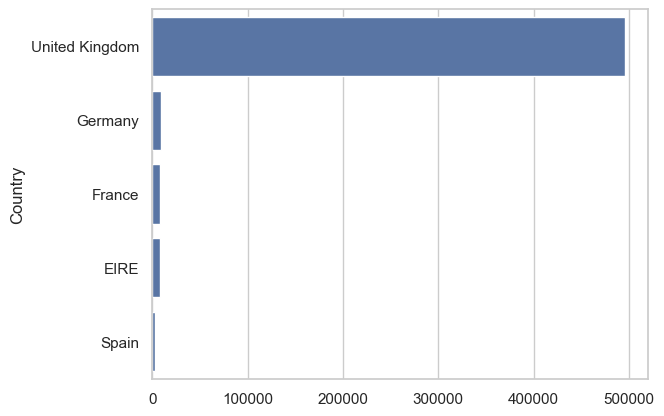

In [60]:
top5 = df['Country'].value_counts().head(5)
sns.barplot(x=top5.values, y=top5.index)
plt.show()

### Escreva 3 insights de negócio baseados nas análises acima.
Use o formato: [Achado] → [Implicação para o negócio].


## Módulo 4 - Valores Ausentes

In [61]:
# 1. Detecção de missings
print(df.isnull().sum())
print((df.isnull().mean()*100).round(2))  # percentual

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


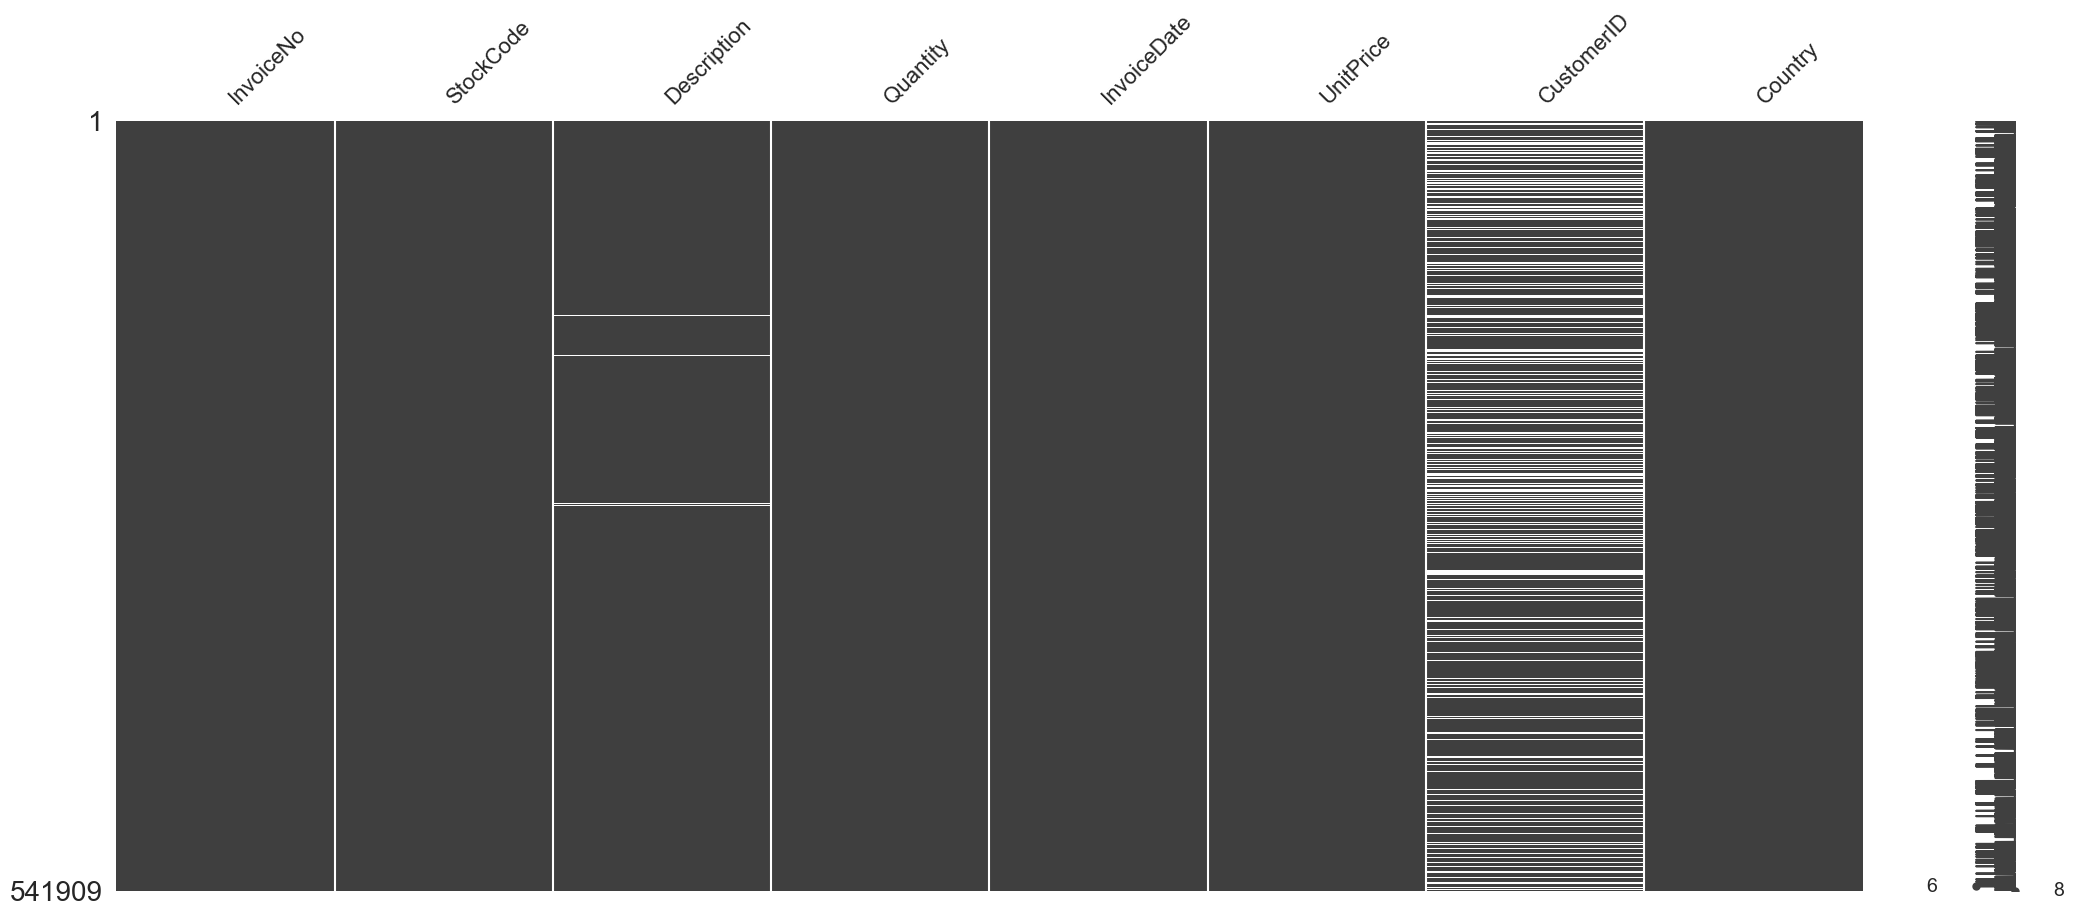

In [62]:
# 2. Visualização com missingno
msno.matrix(df)
plt.show()

In [63]:
# 3. Estratégias de imputação
# Imputar mediana em UnitPrice (poucos missings)
df['UnitPrice'] = df['UnitPrice'].fillna(df['UnitPrice'].median())

In [64]:
# Remover linhas sem CustomerID (muitos missings, MNAR)
df_limpo = df.dropna(subset=['CustomerID'])
print(f"Linhas removidas: {len(df)-len(df_limpo)}")

Linhas removidas: 135080


In [65]:
# KNNImputer (exemplo com colunas numéricas)
imputer = KNNImputer(n_neighbors=5)
df_num = df[['Quantity','UnitPrice']].copy()
df_num_imp = pd.DataFrame(imputer.fit_transform(df_num), columns=df_num.columns)

In [66]:
# 4. Outliers com Z-Score
z_scores = np.abs(stats.zscore(df_limpo['Quantity'].dropna()))
outliers_z = (z_scores > 3).sum()
print(f"Outliers por Z-Score (|z|>3): {outliers_z}")

Outliers por Z-Score (|z|>3): 188


In [67]:
# Filtrar
df_sem_outliers = df_limpo[np.abs(stats.zscore(df_limpo['Quantity'])) <= 3]
print(f"Shape após remoção outliers: {df_sem_outliers.shape}")

Shape após remoção outliers: (406641, 8)


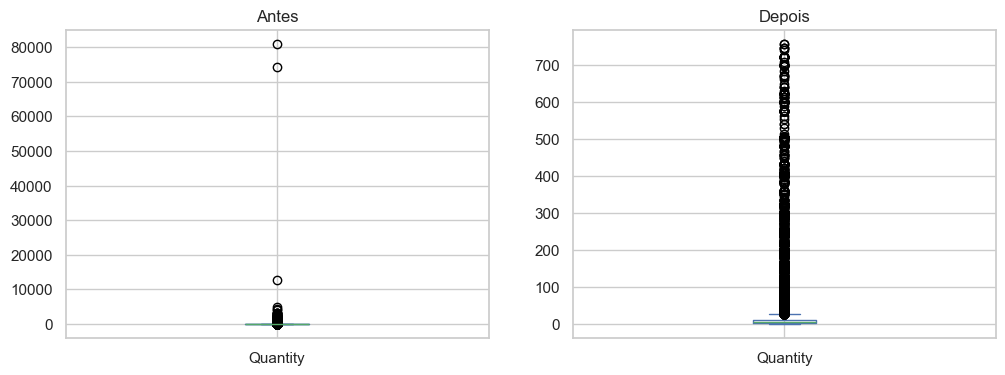

In [68]:
# 5. Boxplot antes e depois
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df_limpo[df_limpo['Quantity']>0]['Quantity'].plot(kind='box', ax=axes[0], title='Antes')
df_sem_outliers[df_sem_outliers['Quantity']>0]['Quantity'].plot(kind='box', ax=axes[1], title='Depois')
plt.show()

## Laboratório 03 - Limpeza

### Mapeie todos os valores ausentes do seu dataset. Use msno.matrix() e isnull().sum(). Qual coluna tem mais missings? Qual o percentual?

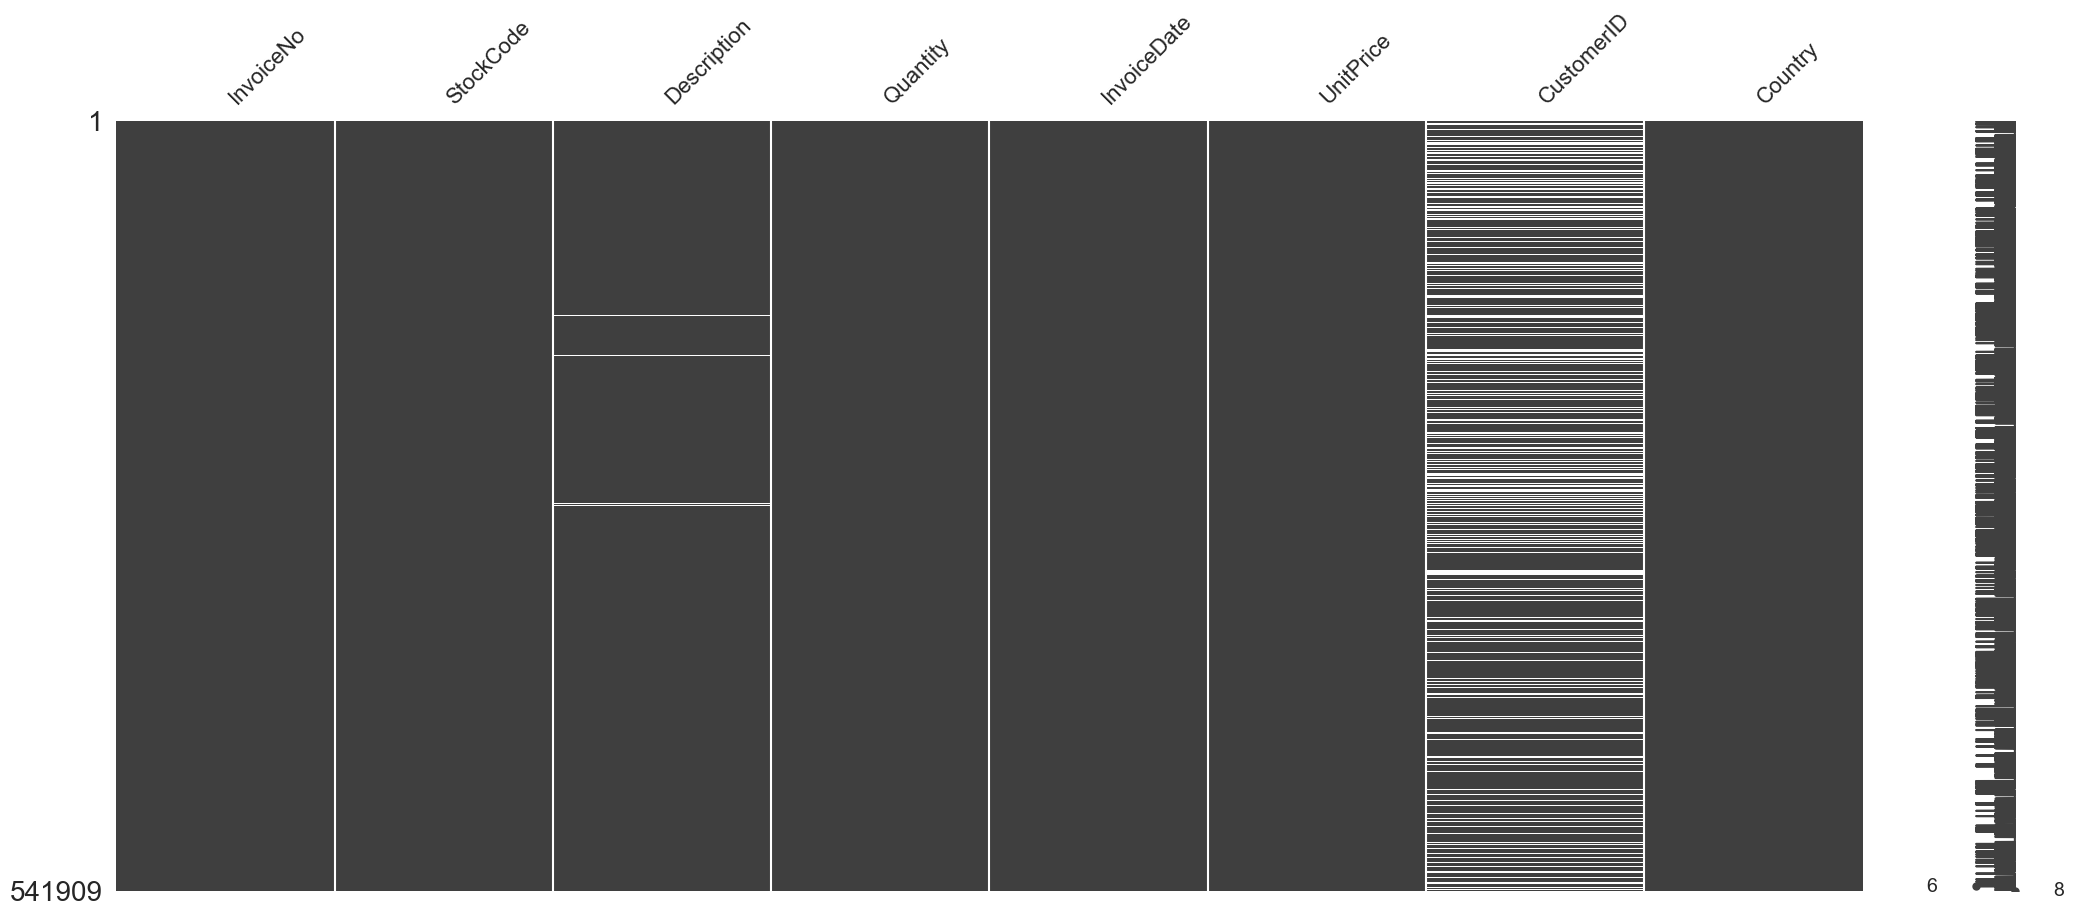

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


In [69]:
msno.matrix(df)
plt.show()
print((df.isnull().mean()*100).round(2))

### Para cada coluna com missing, documente sua decisão: (a) remover linhas, (b) imputar com média/mediana, ou (c) KNNImputer. Justifique a escolha.

Não há resposta única — o critério é a justificativa. Colunas com >40% missing geralmente são removidas; numéricas com baixo % → imputar com mediana.


### Identifique outliers na(s) coluna(s) numérica(s) mais importantes do seu dataset usando Z-Score. Quantas linhas são outliers?

In [71]:
# z = np.abs(stats.zscore(df['coluna_numerica'].dropna()))
z = np.abs(stats.zscore(df['UnitPrice'].dropna()))
print(f'Outliers: {(z>3).sum()}')

Outliers: 374


### Gere um boxplot antes e depois do tratamento de outliers para a variável escolhida. Qual foi o impacto na distribuição?

NameError: name 'df_clean' is not defined

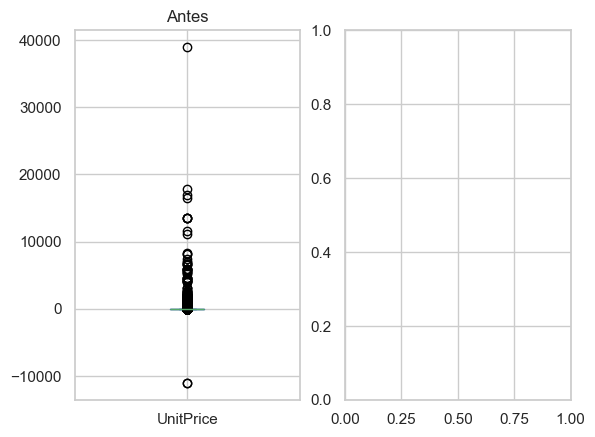

In [ ]:
fig, ax = plt.subplots(1,2)
df['UnitPrice'].plot(kind='box', ax=ax[0], title='Antes')
# df_clean['UnitPrice'].plot(kind='box', ax=ax[1], title='Depois')
plt.show()

### Salve o DataFrame tratado como CSV. Verifique que não há mais missings nas colunas tratadas.

In [ ]:
df_clean.to_csv('projeto_step1_limpeza.csv', index=False)
print(df_clean.isnull().sum())